data = [
("C1", "Hospital", 5),
("C1", "Park", 3),
("C2", "School", 4),
("C2", "Market", 5),
("C3", "Hospital", 2),
("C3", "Market", 4),
("C4", "Park", 5),
("C4", "School", 3),
("C5", "Hospital", 4),
("C5", "School", 5)
]                                                                                                                                                               a) Construct a bipartite graph using citizens and facilities.
b) Use visit/satisfaction score as edge weight.
c) Visualize the bipartite graph with different colors for citizens and facilities.
d) Create a citizen-facility matrix.
e) Apply KMeans clustering to group citizens based on facility usage.
f) Visualize citizen clusters in the graph.                                                                        

In [2]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# -----------------------------
# Data
# -----------------------------
data = [
    ("C1", "Hospital", 5),
    ("C1", "Park", 3),
    ("C2", "School", 4),
    ("C2", "Market", 5),
    ("C3", "Hospital", 2),
    ("C3", "Market", 4),
    ("C4", "Park", 5),
    ("C4", "School", 3),
    ("C5", "Hospital", 4),
    ("C5", "School", 5)
]

df = pd.DataFrame(data, columns=["Citizen", "Facility", "Score"])
print(df)


  Citizen  Facility  Score
0      C1  Hospital      5
1      C1      Park      3
2      C2    School      4
3      C2    Market      5
4      C3  Hospital      2
5      C3    Market      4
6      C4      Park      5
7      C4    School      3
8      C5  Hospital      4
9      C5    School      5


In [3]:
# (a)Construct a bipartite graph using citizens and facilities

B = nx.Graph()

for citizen, facility, score in data:
    B.add_node(citizen,  bipartite=0)
    B.add_node(facility, bipartite=1)
    B.add_edge(citizen, facility, weight=score)

print("Nodes:", list(B.nodes(data=True)))
print("Edges:", list(B.edges(data=True)))

Nodes: [('C1', {'bipartite': 0}), ('Hospital', {'bipartite': 1}), ('Park', {'bipartite': 1}), ('C2', {'bipartite': 0}), ('School', {'bipartite': 1}), ('Market', {'bipartite': 1}), ('C3', {'bipartite': 0}), ('C4', {'bipartite': 0}), ('C5', {'bipartite': 0})]
Edges: [('C1', 'Hospital', {'weight': 5}), ('C1', 'Park', {'weight': 3}), ('Hospital', 'C3', {'weight': 2}), ('Hospital', 'C5', {'weight': 4}), ('Park', 'C4', {'weight': 5}), ('C2', 'School', {'weight': 4}), ('C2', 'Market', {'weight': 5}), ('School', 'C4', {'weight': 3}), ('School', 'C5', {'weight': 5}), ('Market', 'C3', {'weight': 4})]


In [ ]:
# (b) Add weighted edges

for citizen, facility, score in data:
    B.add_edge(citizen, facility, weight=score)

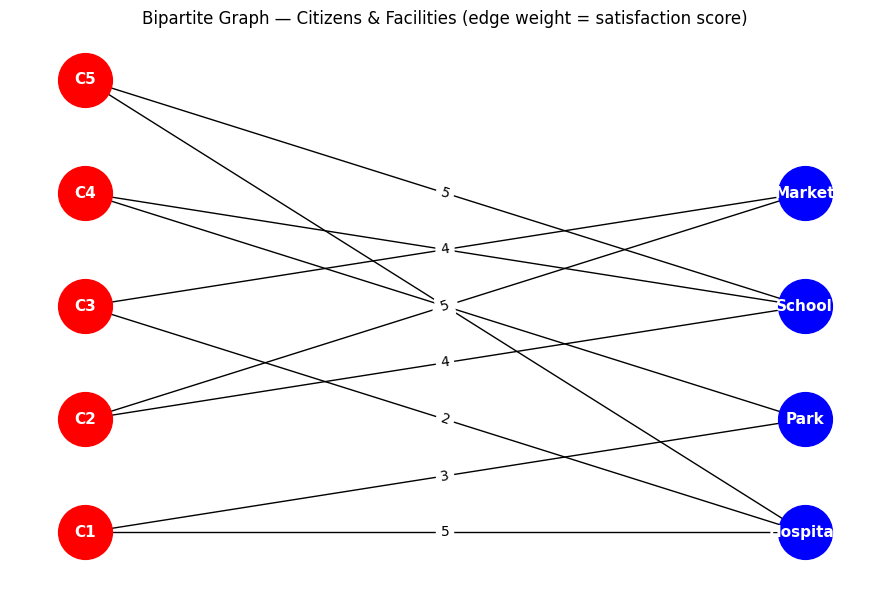

In [4]:
# (c) Visualize Bipartite Graph
#Use satisfaction score as edge weight
# Visualize the bipartite graph with different colors for citizens and facilities

citizen_nodes  = [n for n, d in B.nodes(data=True) if d["bipartite"] == 0]
facility_nodes = [n for n, d in B.nodes(data=True) if d["bipartite"] == 1]

pos = {}
pos.update((n, (0, i)) for i, n in enumerate(citizen_nodes))
pos.update((n, (1, i)) for i, n in enumerate(facility_nodes))

plt.figure(figsize=(9, 6))

nx.draw_networkx_nodes(B, pos, nodelist=citizen_nodes,  node_color="red",  node_size=1500)
nx.draw_networkx_nodes(B, pos, nodelist=facility_nodes, node_color="blue", node_size=1500)
nx.draw_networkx_edges(B, pos)
nx.draw_networkx_labels(B, pos, font_color="white", font_size=11, font_weight="bold")

edge_labels = nx.get_edge_attributes(B, "weight")
nx.draw_networkx_edge_labels(B, pos, edge_labels=edge_labels, font_size=10)

plt.title("Bipartite Graph — Citizens & Facilities (edge weight = satisfaction score)")
plt.axis("off")
plt.tight_layout()
plt.show()

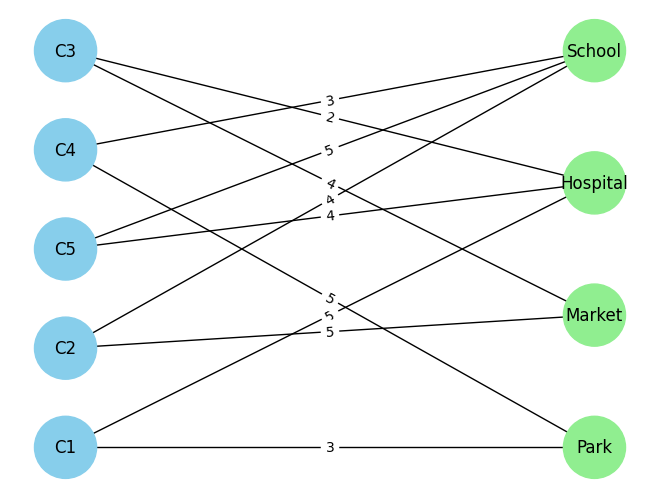

In [ ]:
# eta hbe nah
# (c) Visualize Bipartite Graph

pos = nx.bipartite_layout(B, citizens)

colors = []

for node in B.nodes():
    if node in citizens:
        colors.append("skyblue")
    else:
        colors.append("lightgreen")

nx.draw(B, pos,
        with_labels=True,
        node_color=colors,
        node_size=2000)

nx.draw_networkx_edge_labels(
    B,
    pos,
    edge_labels=nx.get_edge_attributes(B, "weight")
)

plt.show()

In [6]:
# (d) Citizen-Facility Matrix

matrix = df.pivot_table(
    index="Citizen",
    columns="Facility",
    values="Score",
    fill_value=0
).astype(int)

print("Citizen-Facility Matrix")
print(matrix)

Citizen-Facility Matrix
Facility  Hospital  Market  Park  School
Citizen                                 
C1               5       0     3       0
C2               0       5     0       4
C3               2       4     0       0
C4               0       0     5       3
C5               4       0     0       5


In [ ]:
# (e) KMeans Clustering

kmeans = KMeans(n_clusters=2, random_state=42)

matrix["Cluster"] = kmeans.fit_predict(matrix)

print("Citizen Clusters")
print(matrix)


Citizen Clusters
Facility  Hospital  Market  Park  School  Cluster
Citizen                                          
C1             5.0     0.0   3.0     0.0        1
C2             0.0     5.0   0.0     4.0        0
C3             2.0     4.0   0.0     0.0        0
C4             0.0     0.0   5.0     3.0        1
C5             4.0     0.0   0.0     5.0        1


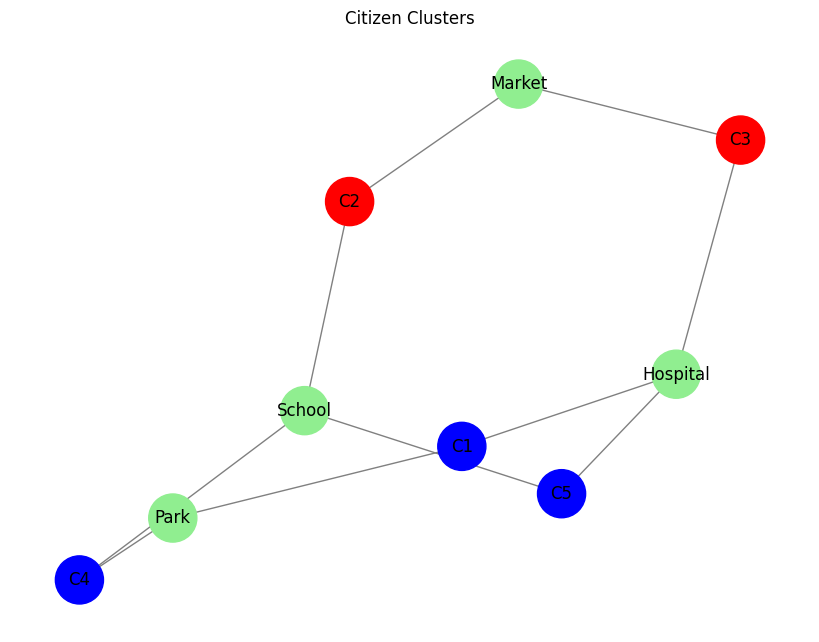

In [12]:
# (f) Visualize Citizen Clusters

cluster_colors = {
    0: "red",
    1: "blue"
}

colors = []

for node in B.nodes():
    if node in citizen_nodes: # Changed 'citizens' to 'citizen_nodes'
        cluster = matrix.loc[node, "Cluster"]
        colors.append(cluster_colors[cluster])
    else:
        colors.append("lightgreen")

plt.figure(figsize=(8,6))

nx.draw(
    B,
    pos,
    with_labels=True,
    node_color=colors,
    node_size=1200,
    edge_color="gray"
)

plt.title("Citizen Clusters")
plt.show()

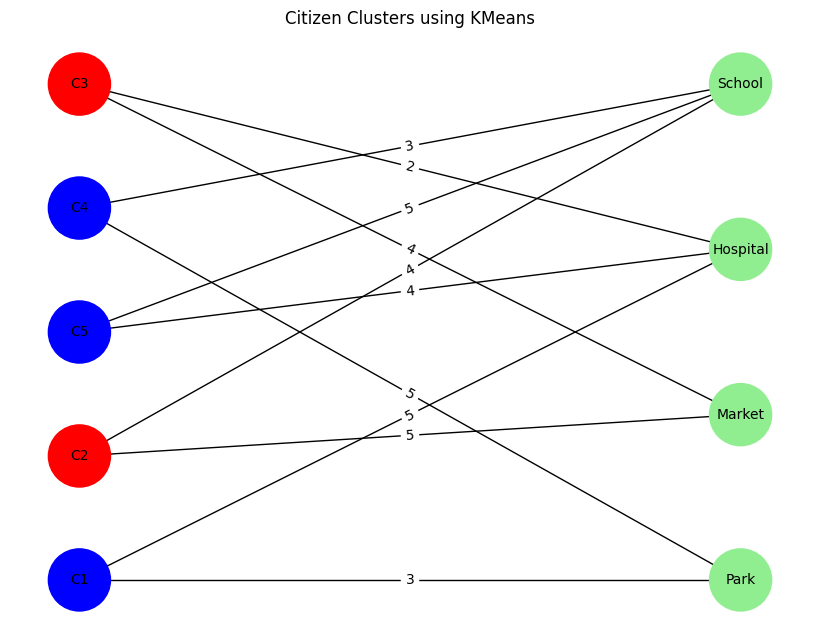

In [ ]:
# (f) Visualize Citizen Clusters

cluster_colors = {
    0: "red",
    1: "blue"
}

colors = []

for node in B.nodes():
    if node in citizens:
        cluster = matrix.loc[node, "Cluster"]
        colors.append(cluster_colors[cluster])
    else:
        colors.append("lightgreen")

plt.figure(figsize=(8,6))

nx.draw(
    B,
    pos,
    with_labels=True,
    node_color=colors,
    node_size=2000,
    font_size=10
)

nx.draw_networkx_edge_labels(
    B,
    pos,
    edge_labels=edge_labels
)

plt.title("Citizen Clusters using KMeans")
plt.show()